In [1]:
from transformers import GPT2LMHeadModel
from transformers import pipeline, set_seed
import matplotlib.pyplot as plt
%matplotlib inline

/Users/lennert/code/zero-to-hero/gpt-from-scratch/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2") # N.B: gpt-2 == 124M model, gpt2-xl is the "actual" GPT2 (1.5B model)
sd_hf = model_hf.state_dict()

for k, v in sd_hf.items():
    print(k, v.shape)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 8211.83it/s]

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

In [3]:
sd_hf["transformer.wpe.weight"].view(-1)[:20]

tensor([-0.0188, -0.1974,  0.0040,  0.0113,  0.0638, -0.1050,  0.0369, -0.1680,
        -0.0491, -0.0565, -0.0025,  0.0135, -0.0042,  0.0151,  0.0166, -0.1381,
        -0.0063, -0.0461,  0.0267, -0.2042])

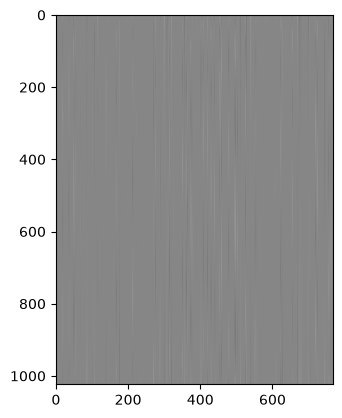

In [4]:
plt.imshow(sd_hf["transformer.wpe.weight"], cmap="gray")

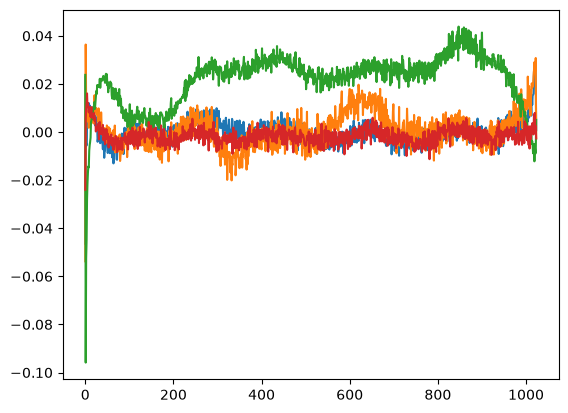

In [5]:
plt.plot(sd_hf["transformer.wpe.weight"][:, 150])
plt.plot(sd_hf["transformer.wpe.weight"][:, 200])
plt.plot(sd_hf["transformer.wpe.weight"][:, 250])
plt.plot(sd_hf["transformer.wpe.weight"][:, 400])

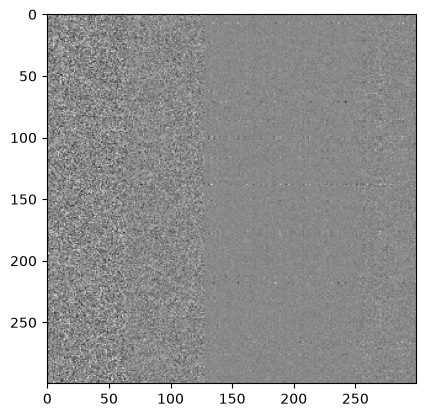

In [6]:
plt.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"][:300, :300], cmap="gray")

In [9]:
generator = pipeline('text-generation', model='gpt2')
set_seed(46)
generator("Happy families are all alike, ", max_length=30, num_return_sequences=5)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 21437.20it/s]
[transformers] Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "Happy families are all alike, \xa0but what about some of them? When I was growing up, I always found myself in the presence of friends who would let me meet up with my cousins and cousins, where I would just go and join them in their car for the night. That's what I would do with my friends. \xa0A lot of times when I was away from home, I would just go out and do what I wanted to do with my friends, but they were always there.\xa0\nThis is why you should not leave your friends alone.\xa0\nI'm sure there are times when we would be there and we would meet up to start a new life. But I think for most of us, when we leave our friends alone, just start new ones in our lives. \xa0It's one thing to tell them that they're great people, but when we're not there, we need to come out andjriwal will take care of us. \xa0I'm sure that he Founders of India, we want to make sure that we have all the amenities that are available, which means that we can only have it if we have all